In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# -----------------------------
# 1) Load dataset from CSV files
# -----------------------------

# Load training and testing CSV files
train_data = pd.read_csv(r"C:\Users\tanay\Downloads\fashion-mnist_train.csv")
test_data = pd.read_csv(r"C:\Users\tanay\Downloads\fashion-mnist_test.csv")

# Class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]



In [3]:
# -----------------------------
# 2) Separate features and labels
# -----------------------------

# First column = labels
y_train = train_data.iloc[:, 0].values
y_test = test_data.iloc[:, 0].values

# Remaining columns = pixel values
x_train = train_data.iloc[:, 1:].values
x_test = test_data.iloc[:, 1:].values

In [4]:
# -----------------------------
# 3) Reshape and normalize data
# -----------------------------

# Reshape into 28x28x1 images
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)



In [5]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data shape:", x_train.shape)
print("Testing data shape :", x_test.shape)

Training data shape: (60000, 28, 28, 1)
Testing data shape : (10000, 28, 28, 1)


In [6]:
# -----------------------------
# 4) Build CNN model
# -----------------------------

model = keras.Sequential([
    
    layers.Input(shape=(28, 28, 1)),

    # First convolution layer
    layers.Conv2D(32, (3, 3), activation="relu"),

    # Pooling layer
    layers.MaxPooling2D((2, 2)),

    # Second convolution layer
    layers.Conv2D(64, (3, 3), activation="relu"),

    # Pooling layer
    layers.MaxPooling2D((2, 2)),

    # Convert matrix to vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Prevent overfitting
    layers.Dropout(0.3),

    # Output layer
    layers.Dense(10, activation="softmax")
])

In [7]:
# -----------------------------
# 5) Compile model
# -----------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# -----------------------------
# 6) Train model
# -----------------------------

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 49s 57ms/step - accuracy: 0.7866 - loss: 0.5853 - val_accuracy: 0.8548 - val_loss: 0.4009
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 77s 51ms/step - accuracy: 0.8595 - loss: 0.3866 - val_accuracy: 0.8857 - val_loss: 0.3207
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 68ms/step - accuracy: 0.8793 - loss: 0.3319 - val_accuracy: 0.8871 - val_loss: 0.3073
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.8920 - loss: 0.2984 - val_accuracy: 0.8935 - val_loss: 0.2929
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.8998 - loss: 0.2728 - val_accuracy: 0.9076 - val_loss: 0.2637
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 31s 42ms/step - accuracy: 0.9071 - loss: 0.2523 - val_accuracy: 0.9057 - val_loss: 0.2605
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.9143 - loss: 0.2337 - val_accuracy: 0.9075 - val_loss: 0.2560
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.9188 - loss: 0.2169 - 

In [9]:
# -----------------------------
# 7) Evaluate model
# -----------------------------

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("\n--- Test Results ---")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss    : {test_loss:.4f}")


--- Test Results ---
Test Accuracy: 0.9105
Test Loss    : 0.2398


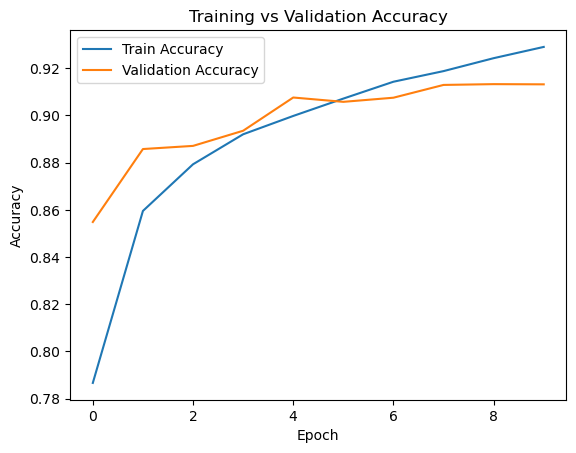

In [10]:
# -----------------------------
# 8) Plot Accuracy Graph
# -----------------------------

plt.figure()

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

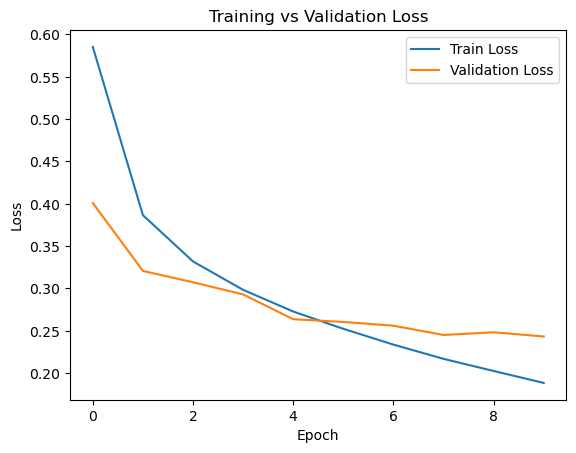

In [11]:
# 9) Plot Loss Graph
# -----------------------------

plt.figure()

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()